In [1]:
%run "/Users/audreyburggraf/Desktop/QUEEN'S/THESIS RESEARCH/PLOTTING C29 989/FUNCTIONS/load_functions"

/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


fortran mie routines unavailable


/opt/anaconda3/lib/python3.9/site-packages/dsharp_opac/dsharp_opac.py:47: UserWarning: could not import compiled mie code - mie calculation will be slow
  warnings.warn(


In [2]:
%run constants.py

In [3]:
# from scipy.special import iv  # modified Bessel function I_0
# from scipy.optimize import minimize_scalar

In [4]:
# # Modified Bessel function of the first kind of real order 
# # https://docs.scipy.org/doc/scipy/reference/generated/scipy.special.iv.html
# from scipy.special import iv  

# # Local minimization of the scalar function of one variable
# # https://docs.scipy.org/doc/scipy/reference/generated/scipy.optimize.minimize_scalar.html
# from scipy.optimize import minimize_scalar # this is the new tnmin

# def bessel_for_debias(P_obs, sigma_PI):

#     def neg_pdf(P_I):
#         x = (P_obs * P_I) / sigma_PI**2
        
#         # (v, z): v is order, z is argument 
#         I_0_x = iv(0, x)
        
#         PDF = (P_obs / sigma_PI**2) * I_0_x * np.exp(-(P_obs**2 + P_I**2) / (2 * sigma_PI**2))
        
#         return - PDF

#     # (function, bounds, method)
#     result = minimize_scalar(neg_pdf, bounds=(0, P_obs), method='bounded')
    
#     return result.x if result.success else 0.0 # return 0 if the minimization was unsuccessful


In [5]:
# from tqdm import tqdm

# def debias_func(POLI_map, POLI_err_map, StokesQ_map, StokesU_map, band):
#     ny, nx = POLI_map.shape
#     POLI_debiased = np.zeros_like(POLI_map)

#     for y in tqdm(range(ny), desc=f"Debiasing {band}"):
#         for x in range(nx):
#             sigma_PI = POLI_err_map[y, x]
#             P_obs = POLI_map[y, x]
#             StokesQ = StokesQ_map[y, x]
#             StokesU = StokesU_map[y, x]
#             S_N = P_obs / sigma_PI

#             if S_N > 9:
#                 debiased = np.sqrt(StokesQ**2 + StokesU**2 - sigma_PI**2)
#             else:
#                 debiased = bessel_for_debias(P_obs, sigma_PI)
               

#             POLI_debiased[y, x] = debiased

#     return POLI_debiased


In [6]:
# # Use the variable from constants.py
# band7_data_folder_path = constants.band7_data_folder_path
# functions_folder_path = constants.functions_folder_path


# Define file paths
StokesI_file = band7_data_folder_path + "IRS63_BAND7_StokesI_clean_nopbcorr.fits"
StokesQ_file = band7_data_folder_path + "IRS63_BAND7_StokesQ_clean_nopbcorr.fits"
StokesU_file = band7_data_folder_path + "IRS63_BAND7_StokesU_clean_nopbcorr.fits"


# Stokes I
# -------------------------------------------------------------------------------------------------------
StokesI_header, _, StokesI_Jy, StokesI_wcs = read_in_file(StokesI_file)
StokesI_mJy = convert_jy_to_mjy(StokesI_Jy)

# Stretch the Stokes I data and get the cbar ticks
StokesI_stretched_mJy, StokesI_unstretched_cbar_ticks = normalize_stokesI_for_cmap(StokesI_mJy)

nx, ny = StokesI_mJy.shape
# -------------------------------------------------------------------------------------------------------
# Stokes I error
# -------------------------------------------------------------------------------------------------------
StokesI_err_mJy = np.full((ny, nx), constants.StokesI_err_mJy_band7)
# -------------------------------------------------------------------------------------------------------


# Stokes Q
# -------------------------------------------------------------------------------------------------------
_, _, StokesQ_Jy, _ = read_in_file(StokesQ_file)
StokesQ_mJy = convert_jy_to_mjy(StokesQ_Jy)
# -------------------------------------------------------------------------------------------------------
# Stokes Q Error
# -------------------------------------------------------------------------------------------------------
StokesQ_err_mJy = np.full((ny, nx), constants.StokesQ_err_mJy_band7)
# -------------------------------------------------------------------------------------------------------


# Stokes U
# -------------------------------------------------------------------------------------------------------
_, _, StokesU_Jy, _ = read_in_file(StokesU_file)
StokesU_mJy = convert_jy_to_mjy(StokesU_Jy)
# -------------------------------------------------------------------------------------------------------
# Stokes U Error
# -------------------------------------------------------------------------------------------------------
StokesU_err_mJy = np.full((ny, nx), constants.StokesQ_err_mJy_band7)
# -------------------------------------------------------------------------------------------------------



In [7]:
# Polarization Intensity
# -------------------------------------------------------------------------------------------------------
POLI_mJy = calculate_polarized_intensity(StokesQ_mJy, StokesU_mJy)

nx, ny = POLI_mJy.shape
# # Ensure POLI_mJy is shaped (ny, nx)
# POLI_mJy_resized = POLI_mJy[:ny, :nx]



# Save data
# hdu = fits.PrimaryHDU(data=POLI_mJy, header=StokesI_header)
# hdu.writeto(band5_data_folder_path + "POLI_mJy_calculated_BAND5.fits", overwrite=True)

# _, _, POLI_Jy, _ = read_in_file(POLI_file)
# POLI_mJy = convert_jy_to_mjy(POLI_Jy)
# -------------------------------------------------------------------------------------------------------
# Polarization Intensity error
# -------------------------------------------------------------------------------------------------------
POLI_err_mJy = calculate_polarized_intensity_err(StokesQ_mJy, StokesU_mJy, StokesQ_err_mJy, StokesU_err_mJy)
# -------------------------------------------------------------------------------------------------------


In [8]:
POLI_debias = debias_func(POLI_mJy, POLI_err_mJy, StokesQ_mJy, StokesU_mJy, 'Band 7')

Debiasing Band 7: 100%|█████████████████████| 1024/1024 [02:49<00:00,  6.05it/s]


In [9]:
# Polarization Angle
# -------------------------------------------------------------------------------------------------------
PA_calc_rad = calculate_polarization_angle(StokesQ_Jy, StokesU_Jy)
PA_rad = PA_calc_rad 
# -------------------------------------------------------------------------------------------------------
# Polarization Angle error
# -------------------------------------------------------------------------------------------------------
PA_err_rad = calculate_polarization_angle_error(StokesQ_mJy, StokesU_mJy, 
                                                StokesQ_err_mJy, StokesU_err_mJy)

PA_err_deg = np.degrees(PA_err_rad)
# -------------------------------------------------------------------------------------------------------


# Polarized Fraction
# -------------------------------------------------------------------------------------------------------
POLF = calculate_polarized_fraction(StokesQ_mJy, StokesU_mJy, StokesI_mJy)
# -------------------------------------------------------------------------------------------------------
# Polarized Fraction Error
# -------------------------------------------------------------------------------------------------------
POLF_err = calculate_polarized_fraction_err(StokesQ_mJy, StokesU_mJy, StokesI_mJy, 
                                            StokesQ_err_mJy, StokesU_err_mJy, StokesI_err_mJy)
# -------------------------------------------------------------------------------------------------------



BMAJ_deg, BMIN_deg, BMAJ_pix, BMIN_pix, BPA_deg_cartesian, reference_length_pix, RA_centre_pix, Dec_centre_pix, xmin, xmax, ymin, ymax = get_plotting_parameters(StokesI_header, StokesI_wcs, 7)





# Find the vectors
# -------------------------------------------------------------------------------------------------------
# in the file:MakingGridFunctions.py make_vectors_band47
results = generate_polarization_vectors_band47(ny, nx,
                                               RA_centre_pix, Dec_centre_pix,
                                               constants.minor_angle_rad_sky_band7,
                                               StokesI_mJy, 
                                               POLI_debias, POLI_err_mJy,
                                               PA_rad, PA_err_deg,
                                               'band 7')
# -------------------------------------------------------------------------------------------------------




# Accessing the actual vector data and angles
vector_data_actual_cartesian = results['vector_data_actual_cartesian']
vector_angle_actual_sky = results['vector_angle_actual_sky']

vector_data_100Uniform_cartesian = results['vector_data_100Uniform_cartesian']
vector_angle_100Uniform_sky = results['vector_angle_100Uniform_sky']

vector_data_100Azimuthal_cartesian = results['vector_data_100Azimuthal_cartesian']
vector_angle_100Azimuthal_sky      = results['vector_angle_100Azimuthal_sky']

StokesQ_grid_100Uniform  = results['StokesQ_grid_100Uniform']
StokesU_grid_100Uniform  = results['StokesU_grid_100Uniform']

StokesQ_grid_100Azimuthal = results['StokesQ_grid_100Azimuthal']
StokesU_grid_100Azimuthal = results['StokesU_grid_100Azimuthal']
# -------------------------------------------------------------------------------------------------------






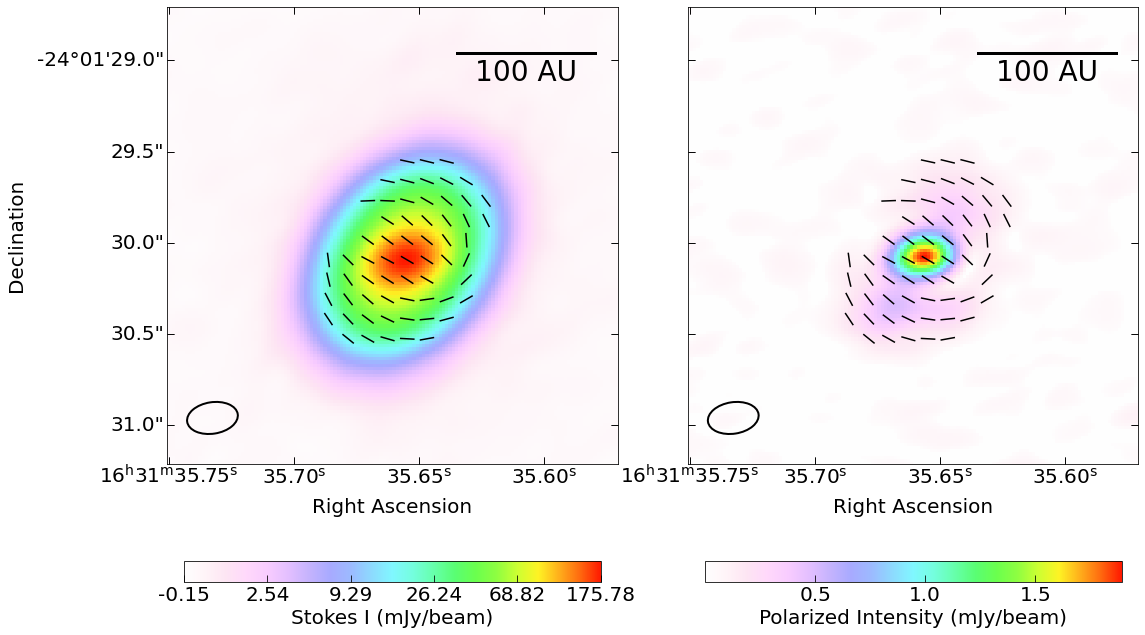

In [10]:
fig, ax = create_stokes_i_plus_one_base_plot(StokesI_wcs, StokesI_stretched_mJy, 
                                             normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                                             POLI_debias, 'Polarized Intensity (mJy/beam)',
                                             soft_colormap_v2, 
                                             xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                                             BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                                             max_length_pix, reference_fraction)

for i in range(2):
    for row in vector_data_actual_cartesian:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='black')
    


In [11]:
hdu = fits.PrimaryHDU(data=POLI_debias, header=StokesI_header)
hdu.writeto(band7_data_folder_path + "POLI_mJy_debias_BAND7_2.fits", overwrite=True)

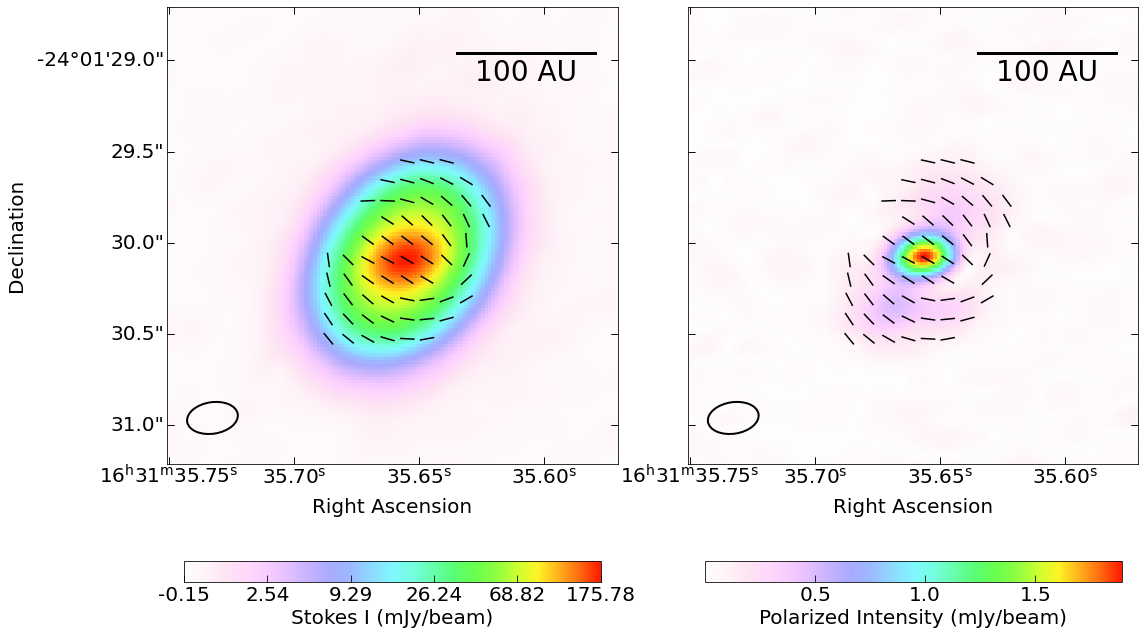

In [12]:
# Find the non-debiased vectors for comparison
# -------------------------------------------------------------------------------------------------------
# in the file:MakingGridFunctions.py make_vectors_band47
results_nodebias = generate_polarization_vectors_band47(ny, nx,
                                                        RA_centre_pix, Dec_centre_pix,
                                                        constants.minor_angle_rad_sky_band7,
                                                        StokesI_mJy, 
                                                        POLI_mJy, POLI_err_mJy,
                                                        PA_rad, PA_err_deg,
                                                        'band 7')
# -------------------------------------------------------------------------------------------------------




# Accessing the actual vector data and anglesf
vector_data_actual_cartesian_nodebias = results_nodebias['vector_data_actual_cartesian']
# -------------------------------------------------------------------------------------------------------



fig, ax = create_stokes_i_plus_one_base_plot(StokesI_wcs, StokesI_stretched_mJy, 
                                             normalized_cbar_ticks, StokesI_unstretched_cbar_ticks, 
                                             POLI_mJy, 'Polarized Intensity (mJy/beam)',
                                             soft_colormap_v2, 
                                             xmin, xmax, ymin, ymax, reference_length_pix, reference_length_AU,
                                             BMAJ_pix, BMIN_pix, BPA_deg_cartesian, 
                                             max_length_pix, reference_fraction)

for i in range(2):
    for row in vector_data_actual_cartesian_nodebias:
        ax[i].plot([row[0], row[1]], [row[2], row[3]], color='black')